In [ ]:
#############################################
##### this is a test script for axolotl tracking 
##### modified based on the original code https://github.com/vivekhsridhar/tracktor/blob/master/examples/3g%20Zebrafish_schooling.ipynb
##### run_1 for all videos in Animal 15, 27, 34, 39
##### add the adaptive threshold searching using the upper quantile of image intensity, change the quantile 0.995
##### add the bigger range for circle searching maxRadius
##### change the circle radius
##### second run for A39 which didn't pass for the frist run
##### 1) manually ajust the circle coordinates and radius for A39_1wpt_5_L2
##### 2) optimize again the circle searching: reduce the distance parameter and ajust the dp parameters to get more fitted circles;  
#####    then select the smallest inner circles
##### 3) add test mode
##### 4) A34 animals for 8wpt using the general parameters for circle searching but threshold_quantile = 0.995; A34_preONT_1 (_2,_3) has issue with circle detection and low intensity of animal
#####    A34_preONT_1 last 1000 frame with no animal detected. circles_dp = 2, circle_dist = 4, circle_offset = 5, threshold_quantile = 0.995
#############################################

In [2]:
import numpy as np
import pandas as pd
import tracktor as tr
import cv2
import sys
import time
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import os
from pathlib import Path
import math
from skimage.io import imread

## Global parameters
This cell (below) enlists user-defined parameters

In [6]:
# colours is a vector of BGR values which are used to identify individuals in the video
# since we only have one individual, the program will only use the first element from this array i.e. (0,0,255) - red
# number of elements in colours should be greater than n_inds (THIS IS NECESSARY FOR VISUALISATION ONLY)
n_inds = 1
#colours = [(255,0,0),(0,255,255),(255,0,255),(255,255,255),(255,255,0),(255,0,0),(0,255,0),(0,0,0)]
colours = [(0,0,255),(0,255,255),(255,0,255), (255,255,0),(255,0,0),(0,255,0)]

# this is the block_size and offset used for adaptive thresholding (block_size should always be odd)
# these values are critical for tracking performance
#block_size = 51
#offset = 20

# the scaling parameter can be used to speed up tracking if video resolution is too high (use value 0-1)
# not use fixed scaling, rather calculate the scaling_img to reduce the all images to 300*300
#scaling = 1.0 

# mot determines whether the tracker is being used in noisy conditions to track a single object or for multi-object
# using this will enable k-means clustering to force n_inds number of animals
mot = False

## parameters added for axolotl images
nb_skippedFrame = 700 # nb of frames to skip to make sure axolotl is there

## parameters for the circle searching
circles_dp = 2
circle_dist = 4
circle_offset = 5

minRadius_init = 120
maxRadius_init = 140


#threshold_value = 120 # threshold used in the gray image to detect axolotl; 
#threshold_quantile = 0.997 #use the adpative thresholding searach, this parameter used when the animal with high intensity and circle border is dim
threshold_quantile = 0.995 # thise parameter is used when the circle border has high intensity or animal intensity is dim

# minimum area and maximum area occupied by the animal in number of pixels
# this parameter is used to get rid of other objects in view that might be hard to threshold out but are differently sized
min_area = 100 
max_area = 800
min_circularity = 0.1 ## minimum circularity of object for detected animal

#### 
display_outFrame = True
test_processing = True

In [7]:
# name of source video and paths
input_vidpath = '/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/Deinz_axolot_tracking/run_1/to_process/A34/' # path to all video folders
output_dir = '/Users/jingkui.wang/workspace/imp/image_analysis_test/results/output_videoTracking_run1/A34/'
codec = 'DIVX' # try other codecs if the default doesn't work ('DIVX', 'avc1', 'XVID') note: this list is non-exhaustive

if test_processing:
    output_dir = output_dir + 'test/'

if not os.path.exists(output_dir):
    os.mkdir(output_dir)
    
print(output_dir)

/Users/jingkui.wang/workspace/imp/image_analysis_test/results/output_videoTracking_run1/A34/test/


In [8]:
directory = Path(input_vidpath)

folder_names = [p.name for p in directory.iterdir() if p.is_dir()]
print(folder_names)
print(len(folder_names))

['A34_preONT_1_L1', 'A34_preONT_2_D1', 'A34_preONT_3_D2']
3


In [9]:
## test only specific video
#folder_names = folder_names[0:3]

#print(folder_names)
#if isinstance(folder_names, str):
#    folder_names = [folder_names]
#for folder in folder_names:
#    print(folder)
print(folder_names)
print(len(folder_names))

['A34_preONT_1_L1', 'A34_preONT_2_D1', 'A34_preONT_3_D2']
3


In [10]:
###############################################
##### run all videos in the specified folders
###############################################

In [ ]:
if isinstance(folder_names, str):
    folder_names = [folder_names]
    
for folder in folder_names:
    
    ## Start time
    start = time.time()
    
    print(folder)
    
    video = folder
    output_vidpath = output_dir + video + '.mp4'
    output_filepath = output_dir + video + '.csv'
    output_figpath = output_dir + video + '.pdf'
    output_error = output_dir + video + '_error.csv'
    output_circle = output_dir + video + '_circle.csv'
    
    video_path = Path(input_vidpath + folder + '/')
    first_file = next(p.name for p in video_path.iterdir() if p.is_file())
    #files = [p for p in video_path.iterdir() if p.is_file()]
    #first_file = files[0].name
    file_name = Path(first_file).stem
    #print(file_name)
    file_split = file_name.split("_")
    f_newname = "_".join(file_split[:-1])
    
    print(f_newname)
    #'1_D1_test/Basler_acA2040-120um__24899445__20260407_140424600_%04d.tiff'
    
    ##########
    # check first the shape of image to determine the scaling parameter
    ##########
    img = imread(input_vidpath + '/' + folder + '/' + f_newname + '_0000.tiff')
    scaling_img_0 = 300/img.shape[0]
    scaling_img_1 = 300/img.shape[1]
    
    print('image size : ' + str(img.shape[0]) + ', ' + str(img.shape[1]))
    print('scaling factor : ' + str(scaling_img_0) + ',' + str(scaling_img_1))
    
    del img
    
    ###################################################
    ### loop over videos
    ###################################################
    ## Open video
    cap = cv2.VideoCapture(input_vidpath + '/' + folder + '/' + f_newname + '_%04d.tiff')
    
    if cap.isOpened() == False:
        sys.exit('Video file cannot be read! Please check input_vidpath to ensure it is correctly pointing to the video file')

    ## Video writer class to output video with contour and centroid of tracked object(s)
    # make sure the frame size matches size of array 'final'
    fourcc = cv2.VideoWriter_fourcc(*codec)
    output_framesize = (int(cap.read()[1].shape[1]*scaling_img_1), int(cap.read()[1].shape[0]*scaling_img_0))
    print('output_framesize -- ' + str(output_framesize[0]) + ', ' +  str(output_framesize[1]))
    
    out = cv2.VideoWriter(filename = output_vidpath, fourcc = fourcc, fps = 30.0, frameSize = output_framesize, isColor = True)

    ## Individual location(s) measured in the last and current step
    meas_last = list(np.zeros((n_inds,2)))
    meas_now = list(np.zeros((n_inds,2)))
    
    last = 0
    df = []
    err = []
    
    ## first frame to detect the coordinate and radius of circles
    #cap.set(1,1)
    ## strat the tracing from the frame 500 to skip those without axolotl
    cap.set(1, nb_skippedFrame)
    
    ret, frame = cap.read()
    
    frame = cv2.resize(frame, None, fx = scaling_img_1, fy = scaling_img_0, interpolation = cv2.INTER_LINEAR)
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur_frame = cv2.medianBlur(gray_frame, 5)
    
    ####################
    ## circle searching
    ## add adapt circle searching with maxRadius
    ####################
    
    #circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 50, minRadius = 120, maxRadius = maxRadius_init)
    circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, dp = circles_dp, minDist = circle_dist, param1=100, param2=50, minRadius = minRadius_init, maxRadius = maxRadius_init) ## add param1 and param2; reduce the distance 
    
    if circles is None:
        #circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 50, minRadius = 120, maxRadius = (maxRadius_init + 5))
        circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, dp = circles_dp, minDist = circle_dist, param1=100, param2=50, minRadius = minRadius_init, maxRadius = (maxRadius_init + 5)) ## add param1 and param2; reduce the distance 
        
        if circles is None:
            #circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 50, minRadius = 120, maxRadius = (maxRadius_init + 10))
            circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, dp = circles_dp, minDist = circle_dist, param1=100, param2=50, minRadius = minRadius_init, maxRadius = (maxRadius_init + 10)) 
            
    
    if circles is not None:
        #circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 10, minRadius = 120, maxRadius = 150)
        #circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 50, minRadius = 120, maxRadius = 140)
        
        circles = np.round(circles[0, :]).astype("int")

        # Sort by radius, smallest first
        circles = sorted(circles, key=lambda c: c[2])

        # Smallest circle with general parameteres
        circle_run = circles[0]
        
        circle_x = circle_run[0]
        circle_y = circle_run[1] 
        circle_radius = circle_run[2] - circle_offset
        
        #circles = np.uint8(np.around(circles))
        print(circle_run)
        #if len(circles) == 1:
        #    circle_run = circles[0,:][0]
        #else:
        #    print(' > 1 circles found but select the first one ')
        #    circle_run = circles[0,:][0]
        #circle_x = circle_run[0]
        
        ## general parameters
        #circle_y = circle_run[1]
        #circle_radius = 130
        #circle_radius = circle_run[2] - 2
        
        # ajust parameter for A39_1wpt_5_L2
        #circle_y = circle_run[1] + 3
        #circle_radius = circle_run[2] - 5
        
        circle_position = [circle_x, circle_y, circle_radius]
        
        circle_position = pd.DataFrame(np.matrix(circle_position), columns = ['x','y','radius'])
        circle_position.to_csv(output_circle, sep=',')
        
    else:
        print(' no circles found !!! ')
        #break
        continue
    
    while(True):
        # Capture frame-by-frame
        ret, frame = cap.read()
        
        this = cap.get(1)
    
        if ret == True:
            frame = cv2.resize(frame, None, fx = scaling_img_1, fy = scaling_img_0, interpolation = cv2.INTER_LINEAR)
        
            # Apply mask to the area of interest
            mask = np.zeros(frame.shape)
            #mask = cv2.circle(mask, (308, 235), 215, (255,255,255), -1)
            #mask = cv2.circle(mask, (147, 155), 130, (255,255,255), -1)
            mask = cv2.circle(mask, (circle_x, circle_y), circle_radius, (255,255,255), -1)
            
            #frame[mask ==  0] = np.median(frame[mask >  0])
            frame[mask ==  0] = 0
        
            blur = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            blur = cv2.medianBlur(blur, 5)
            
            threshold_value = np.quantile(blur.ravel(), threshold_quantile)
            
            _, binary = cv2.threshold(blur, threshold_value, 255, cv2.THRESH_BINARY)
            #thresh = tr.colour_to_thresh(frame, block_size, offset)
            thresh = binary
            final, contours, meas_last, meas_now = tr.detect_and_draw_contours(frame, thresh, meas_last, meas_now, min_area, max_area, 
                                                                               min_circularity = 0.1)
            try:
                row_ind, col_ind = tr.hungarian_algorithm(meas_last, meas_now)
                final, meas_now, df = tr.reorder_and_draw(final, colours, n_inds, col_ind, meas_now, df, mot, this)
            except:
                #print(this,  "frame Error")
                err.append([f_newname, this])
                continue
            
            # Create output dataframe
            for i in range(n_inds):
                df.append([this, meas_now[i][0], meas_now[i][1]])
        
            # Display the resulting frame
            out.write(final)
            
            cv2.imshow('frame', final)
            if cv2.waitKey(1) == 27:
                break
            
            
        if last == this:
            break
    
        last = this
    
    ## Write positions to file
    if len(df) > 0:
        df = pd.DataFrame(np.matrix(df), columns = ['frame','pos_x','pos_y'])
        df.to_csv(output_filepath, sep=',')

    if len(err) > 0:
        err = pd.DataFrame(np.matrix(err), columns = ['video','frame'])
        err.to_csv(output_error, sep=',')
    
    ## When everything done, release the capture
    cap.release()
    out.release()
    cv2.destroyAllWindows()
    cv2.waitKey(1)

    ####################################
    # Plot tracks
    # The code below allows you to see individual tracks. By counting the number of jumps in the tracks, one can identify number of false detections.
    ####################################
    #if Path(output_filepath).is_file():
    if os.path.isfile(output_filepath):
        df = pd.read_csv(output_filepath)
        
        plt.figure(figsize=(8, 8))
        plt.scatter(df['pos_x'], df['pos_y'], c=df['frame'])
        plt.xlabel('pos_x')
        plt.ylabel('pos_y')
        plt.savefig(output_figpath, format = 'pdf', bbox_inches="tight")
        plt.close()
        
    else:
        print(' no frame processed !!! ')
        
    ## End time and duration
    end = time.time()
    duration = np.around((end - start)/60)
    
    print("--- %s minutes ---" %duration)
    

A34_preONT_1_L1
Basler_acA2040-120um__24899445__20260326_115224187
image size : 600, 600
scaling factor : 0.5,0.5
output_framesize -- 300, 300


OpenCV: FFMPEG: tag 0x58564944/'DIVX' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


[131 165 121]
--- 37.0 minutes ---
A34_preONT_2_D1
Basler_acA2040-120um__24899445__20260326_134245859
image size : 600, 600
scaling factor : 0.5,0.5
output_framesize -- 300, 300


OpenCV: FFMPEG: tag 0x58564944/'DIVX' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


[133 163 121]
--- 32.0 minutes ---
A34_preONT_3_D2
Basler_acA2040-120um__24899445__20260326_144059657
image size : 600, 600
scaling factor : 0.5,0.5
output_framesize -- 300, 300


OpenCV: FFMPEG: tag 0x58564944/'DIVX' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


[131 165 121]


In [ ]:
###########################################################
###########################################################
## debug specific folder or file
###########################################################
###########################################################

In [40]:
from pathlib import Path
directory = Path(input_vidpath)

folder_names = [p.name for p in directory.iterdir() if p.is_dir()]
print(folder_names)

['A34_preONT_1_L1', 'A34_preONT_2_D1', 'A34_preONT_3_D2']


In [41]:
## test only specific video
folder_names = folder_names[0]
#print(folder_names)
if isinstance(folder_names, str):
    folder_names = [folder_names]
for folder in folder_names:
    print(folder)

A34_preONT_1_L1


In [42]:
#folder = 'A34_1wpt_3_D2'
#folder = 'A15_1wpt_1_D1'
#folder = 'A34_1wpt_2_L1'

In [43]:
print(output_dir)

/Users/jingkui.wang/workspace/imp/image_analysis_test/results/output_videoTracking_run1/A34/test/


In [44]:
input_vidpath
video = folder
output_vidpath = output_dir + video + '.mp4'
output_filepath = output_dir + video + '.csv'
output_figpath = output_dir + video + '.pdf'
output_error = output_dir + video + '_error.csv'
output_circle = output_dir + video + '_circle.csv'


In [45]:
video_path = Path(input_vidpath + folder + '/')
first_file = next(p.name for p in video_path.iterdir() if p.is_file())
#files = [p for p in video_path.iterdir() if p.is_file()]
#first_file = files[0].name
file_name = Path(first_file).stem
#print(file_name)
file_split = file_name.split("_")
f_newname = "_".join(file_split[:-1])
    
print(f_newname)

##########
# check first the shape of image to determine the scaling parameter
##########
img = imread(input_vidpath + '/' + folder + '/' + f_newname + '_0000.tiff')
#scaling_img = 300/img.shape[0]
scaling_img_0 = 300/img.shape[0]
scaling_img_1 = 300/img.shape[1]
    
print('image size : ' + str(img.shape[0]) + ', ' + str(img.shape[1]))
print('scaling factor : ' + str(scaling_img_0) + ',' + str(scaling_img_1))
    
del img
#print(scaling_img)

Basler_acA2040-120um__24899445__20260326_115224187
image size : 600, 600
scaling factor : 0.5,0.5


In [130]:
cap = cv2.VideoCapture(input_vidpath + '/' + folder + '/' + f_newname + '_%04d.tiff')
    
if cap.isOpened() == False:
    sys.exit('Video file cannot be read! Please check input_vidpath to ensure it is correctly pointing to the video file')

## Video writer class to output video with contour and centroid of tracked object(s)
# make sure the frame size matches size of array 'final'
fourcc = cv2.VideoWriter_fourcc(*codec)
output_framesize = (int(cap.read()[1].shape[1]*scaling_img_1), int(cap.read()[1].shape[0]*scaling_img_0))
print('output_framesize -- ' + str(output_framesize[0]) + ',' + str(output_framesize[1]))
    
out = cv2.VideoWriter(filename = output_vidpath, fourcc = fourcc, fps = 30.0, frameSize = output_framesize, isColor = True)

## Individual location(s) measured in the last and current step
meas_last = list(np.zeros((n_inds,2)))
meas_now = list(np.zeros((n_inds,2)))
    
last = 0
df = []
err = []

output_framesize -- 300,300


OpenCV: FFMPEG: tag 0x58564944/'DIVX' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


In [154]:
cap.set(1, 700)
threshold_value = 120
ret, frame = cap.read()
#frame = cv2.resize(frame, None, fx = scaling_img, fy = scaling_img, interpolation = cv2.INTER_LINEAR)
frame = cv2.resize(frame, None, fx = scaling_img_1, fy = scaling_img_0, interpolation = cv2.INTER_LINEAR)
gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
blur_frame = cv2.medianBlur(gray_frame, 5)

In [155]:
this = cap.get(1)
print(this)

701.0


In [172]:
#gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
#blur_frame = cv2.medianBlur(gray_frame, 5)
print(blur_frame.shape)
import math

#minRadius_circle = math.floor(120 * (blur_frame.shape[1]/300))
#maxRadius_circle = math.floor(140 * (blur_frame.shape[1]/300))


#circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 4, minRadius = 120, maxRadius = 140)
#circles = np.uint8(np.around(circles))

circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, dp = 2, minDist = 4, 
                           param1=100, param2=50, 
                           minRadius = minRadius_init, maxRadius = maxRadius_init) ## add param1 and param2; reduce the distance 
    
#circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, dp = 1.5, minDist = 2, param1=100, param2=50, minRadius = 120, maxRadius = 140)
#circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 50, minRadius = 120, maxRadius = maxRadius_init)

if circles is not None:
    circles = np.round(circles[0, :]).astype("int")

    # Sort by radius, smallest first
    circles = sorted(circles, key=lambda c: c[2])

    # Smallest circle
    circle_run = circles[0]
    circle_x = circle_run[0]
    circle_y = circle_run[1] 
    circle_radius = circle_run[2]  - 5
    #circle_radius = circle_run[2] - 5
        
    circle_position = [circle_x, circle_y, circle_radius]
    
print(circles)
print(circle_position)

#circles = np.uint8(np.around(circles))    
#if len(circles) == 1:
#   circle_run = circles[0,:][0]
           #circle_position = pd.DataFrame(np.matrix(circle_position), columns = ['x','y','radius'])
    #circle_position.to_csv(output_circle, sep=',')
#print(circles)

(300, 300)
[array([131, 165, 121]), array([165, 163, 123]), array([141, 157, 134]), array([149, 151, 137]), array([141, 143, 139]), array([159, 143, 139])]
[np.int64(131), np.int64(165), np.int64(116)]


In [173]:
#cap.set(1, nb_skippedFrame)

In [174]:
#ret, frame = cap.read()
#frame = cv2.resize(frame, None, fx = scaling_img, fy = scaling_img, interpolation = cv2.INTER_LINEAR)
#plt.imshow(frame,'gray')

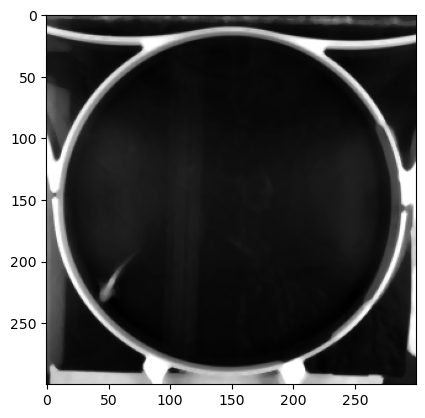

In [175]:
plt.imshow(blur_frame,'gray')

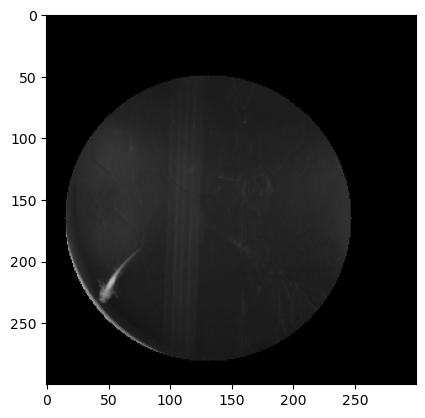

In [176]:
# Apply mask to the area of interest
mask = np.zeros(frame.shape)
#mask = cv2.circle(mask, (147, 155), 130, (255,255,255), -1)
mask = cv2.circle(mask, (circle_x, circle_y), circle_radius, (255,255,255), -1)
frame[mask ==  0] = 0
plt.imshow(frame,'gray')

In [177]:
blur = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
blur = cv2.medianBlur(blur, 5)

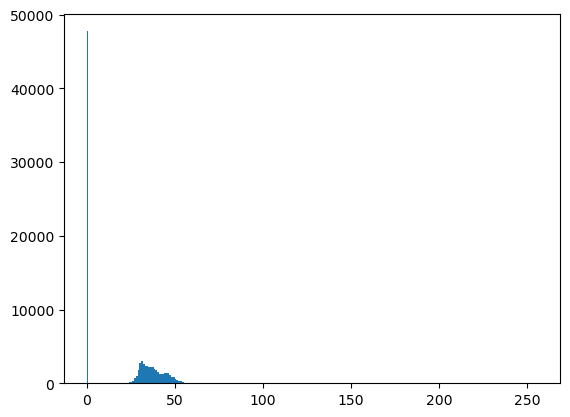

In [178]:
plt.hist(blur.ravel(), bins=256, range=(0, 256))
plt.show()

In [179]:
from scipy.stats import percentileofscore
print(percentileofscore(blur.ravel(), 120))
a = blur.ravel()
len(a)
blur.shape

99.90444444444445


(300, 300)

In [180]:
print((blur.ravel() > 120).sum())
print(1-(blur.ravel() > 120).sum()/300/300)

86
0.9990444444444444


In [181]:
print(np.quantile(blur.ravel(), 0.995))
print(np.quantile(blur.ravel(), 0.999))

59.0
118.00100000000384


In [182]:
threshold_value = np.quantile(blur.ravel(), 0.995)
print((blur.ravel() >= threshold_value).sum())
print(threshold_value)
#threshold_value = 120

456
59.0


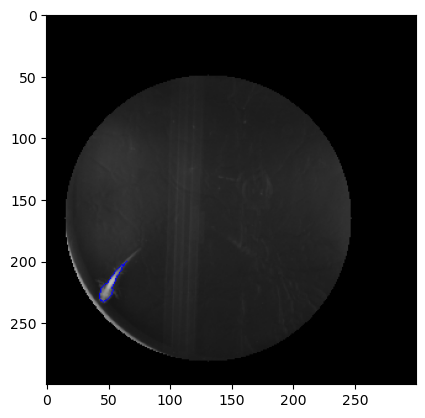

In [183]:
_, binary = cv2.threshold(blur, threshold_value, 255, cv2.THRESH_BINARY)
#thresh = tr.colour_to_thresh(frame, block_size, offset)
thresh = binary
final, contours, meas_last, meas_now = tr.detect_and_draw_contours(frame, thresh, meas_last, meas_now, min_area, max_area, min_circularity = 0.1)
plt.imshow(final,'gray')

In [184]:
print(min_area, max_area)

100 800


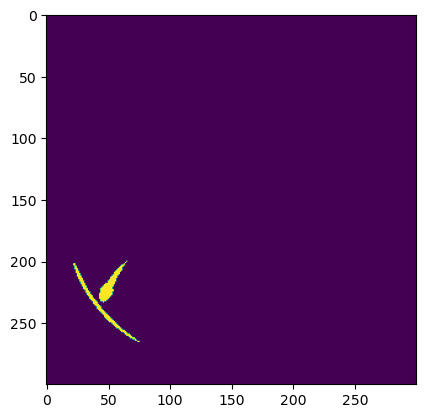

In [185]:
plt.imshow(binary)

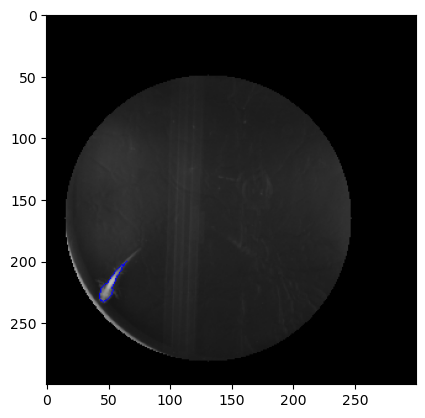

In [186]:
plt.imshow(final)

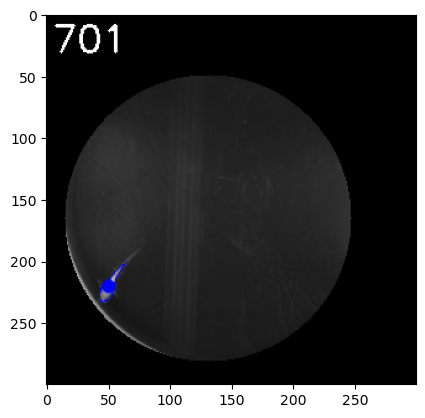

In [171]:
row_ind, col_ind = tr.hungarian_algorithm(meas_last, meas_now)
final, meas_now, df = tr.reorder_and_draw(final, colours, n_inds, col_ind, meas_now, df, mot, this)
plt.imshow(final,'gray')

In [30]:
#### start to run specific examples

In [31]:
print(circle_position)

[np.int64(148), np.int64(149), np.int64(121)]


In [32]:
circle_position = pd.DataFrame(np.matrix(circle_position), columns = ['x','y','radius'])
circle_position.to_csv(output_circle, sep=',')

In [33]:
start = time.time()
while(True):
    # Capture frame-by-frame
    ret, frame = cap.read()
        
    this = cap.get(1)
    
    if ret == True:
        frame = cv2.resize(frame, None, fx = scaling_img_1, fy = scaling_img_0, interpolation = cv2.INTER_LINEAR)
        
        # Apply mask to the area of interest
        mask = np.zeros(frame.shape)
        mask = cv2.circle(mask, (circle_x, circle_y), circle_radius, (255,255,255), -1)
            
        frame[mask ==  0] = 0
        
        blur = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        blur = cv2.medianBlur(blur, 5)
            
        threshold_value = np.quantile(blur.ravel(), threshold_quantile)
            
        _, binary = cv2.threshold(blur, threshold_value, 255, cv2.THRESH_BINARY)
        #thresh = tr.colour_to_thresh(frame, block_size, offset)
        thresh = binary
        final, contours, meas_last, meas_now = tr.detect_and_draw_contours(frame, thresh, meas_last, meas_now, min_area, max_area, 
                                                                               min_circularity = 0.1)
            
        try:
            row_ind, col_ind = tr.hungarian_algorithm(meas_last, meas_now)
            final, meas_now, df = tr.reorder_and_draw(final, colours, n_inds, col_ind, meas_now, df, mot, this)
        except:
            #print(this,  "frame Error")
            err.append([f_newname, this])
                
            continue
            
        # Create output dataframe
        for i in range(n_inds):
            df.append([this, meas_now[i][0], meas_now[i][1]])
        
        # Display the resulting frame
        out.write(final)
        cv2.imshow('frame', final)
        if cv2.waitKey(1) == 27:
            break
               
    if last == this:
        break
    
    last = this
    
## Write positions to file
if len(df) > 0:
    df = pd.DataFrame(np.matrix(df), columns = ['frame','pos_x','pos_y'])
    df.to_csv(output_filepath, sep=',')

if len(err) > 0:
    err = pd.DataFrame(np.matrix(err), columns = ['video','frame'])
    err.to_csv(output_error, sep=',')
    
## When everything done, release the capture
cap.release()
out.release()
cv2.destroyAllWindows()
cv2.waitKey(1)

####################################
# Plot tracks
# The code below allows you to see individual tracks. By counting the number of jumps in the tracks, one can identify number of false detections.
####################################
#if Path(output_filepath).is_file():
if os.path.isfile(output_filepath):
    df = pd.read_csv(output_filepath)
        
    plt.figure(figsize=(8, 8))
    plt.scatter(df['pos_x'], df['pos_y'], c=df['frame'])
    plt.xlabel('pos_x')
    plt.ylabel('pos_y')
    plt.savefig(output_figpath, format = 'pdf', bbox_inches="tight")
    plt.close()
        
else:
    print(' no frame processed !!! ')
        
## End time and duration
end = time.time()
duration = np.around((end - start)/60)
    
print("--- %s minutes ---" %duration)

--- 28.0 minutes ---
